# 2. High-Dimensional Analysis & Manifold Learning

**Objective**: Explore the non-linear structure of the neural manifold using UMAP and identify discrete brain states using Clustering.

**Steps**:
1.  Load Preprocessed Data.
2.  **Image Complexity**: Correlate neural activity with visual stimulus complexity.
3.  **UMAP**: Unfold the manifold in 2D and 3D.
4.  **Clustering**: Identify and visualize distinct brain states (K-Means).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
import plotly.express as px
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Import Architectural Style
import viz_style
viz_style.set_architectural_style()

# Load Data
session_id = 715093703
input_file = Path(f"../Dataset/Processed/{session_id}/average_response_matrix.pkl")

if input_file.exists():
    average_response_matrix_total = pd.read_pickle(input_file)
    print(f"Loaded data from {input_file}")
else:
    print(f"Error: Data file not found at {input_file}")

# Load Cache for Movie Template
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
movie_template = cache.get_natural_movie_template(1)
print(f"Movie Template Loaded: {movie_template.shape}")

Architectural plot style applied (Dark Mode).
Loaded data from ../Dataset/Processed/715093703/average_response_matrix.pkl
Movie Template Loaded: (900, 304, 608)


### Step 2: Image Complexity Analysis
Calculate the visual complexity (edge density) of each movie frame to see if it drives neural state transitions.

Complexity Calculated. Min: 2.4984, Max: 4.8232


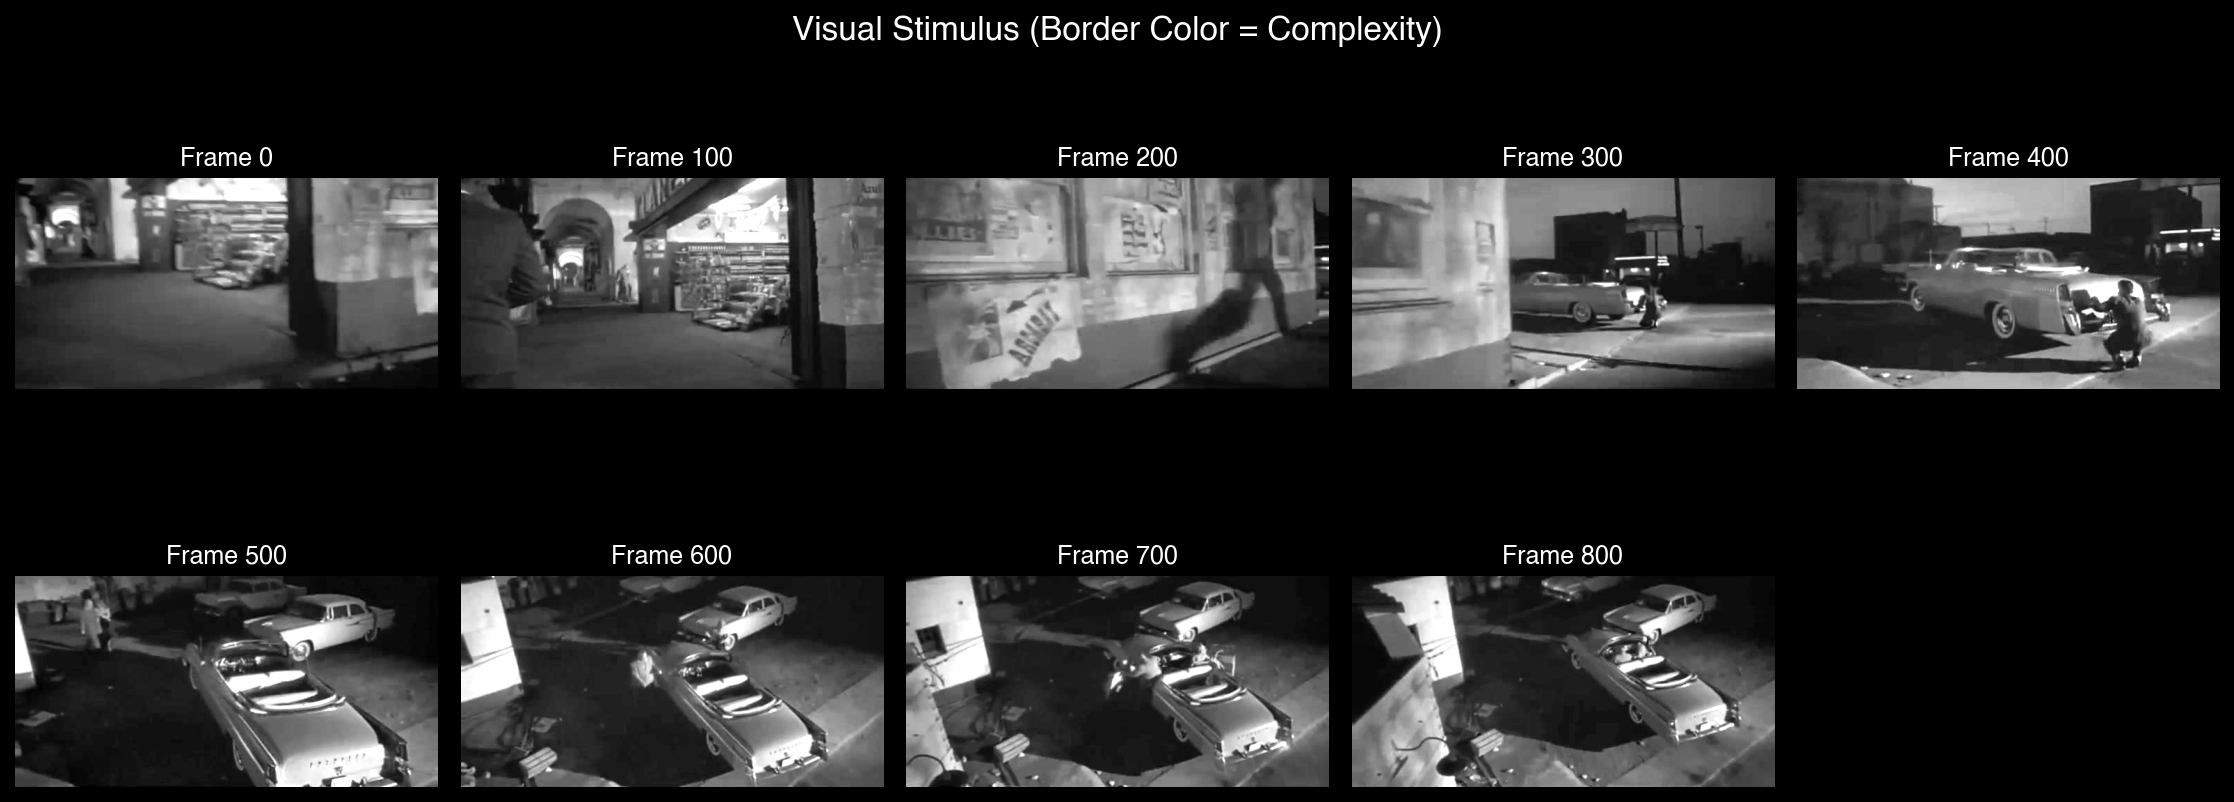

In [7]:
def get_image_complexity(img):
    gy, gx = np.gradient(img)
    gnorm = np.sqrt(gx**2 + gy**2)
    return np.mean(gnorm)

frame_complexity = np.array([get_image_complexity(frame) for frame in movie_template])
print(f"Complexity Calculated. Min: {frame_complexity.min():.4f}, Max: {frame_complexity.max():.4f}")

# Visualize Stimulus vs Complexity
interval = 100
total_frames = len(movie_template)
sample_frames = np.arange(0, total_frames, interval)

cols = 5
rows = (len(sample_frames) // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

min_c, max_c = frame_complexity.min(), frame_complexity.max()

for i, frame_idx in enumerate(sample_frames):
    if frame_idx < total_frames:
        img = movie_template[frame_idx, :, :]
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Frame {frame_idx}")
        axes[i].axis('off')
        
        # Border color by complexity
        norm_complexity = (frame_complexity[frame_idx] - min_c) / (max_c - min_c)
        color = plt.cm.viridis(norm_complexity)
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(f"Visual Stimulus (Border Color = Complexity)", fontsize=16, y=1.02)
plt.show()

### Step 2.5: Linear Dimensionality Reduction (PCA)
Visualize the neural population trajectory in 3D PCA space, colored by visual stimulus features (Illuminance and Complexity).

In [ ]:
# PCA Calculation
X = average_response_matrix_total.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f"Original Shape: {X.shape}")
print(f"Reduced Shape: {X_pca.shape}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_} (Total: {sum(pca.explained_variance_ratio_):.2%})")

# Calculate Illuminance (Frame Brightness)
frame_brightness = np.mean(movie_template, axis=(1, 2))

# 1. PCA Colored by Illuminance
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=frame_brightness, cmap='viridis', s=20, alpha=0.8)
ax.plot(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], color='gray', alpha=0.3, linewidth=0.8)

ax.text(X_pca[0, 0], X_pca[0, 1], X_pca[0, 2], "Start", color='red', fontsize=12, fontweight='bold')
ax.text(X_pca[-1, 0], X_pca[-1, 1], X_pca[-1, 2], "End", color='blue', fontsize=12, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')
ax.set_title('Neural Population Trajectory (PCA) - Colored by Illuminance')

plt.colorbar(sc, label='Frame Brightness (Illuminance)')
plt.tight_layout()
plt.show()

# 2. PCA Colored by Image Complexity
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=frame_complexity, cmap='viridis', s=20, alpha=0.8)
ax.plot(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], color='gray', alpha=0.3, linewidth=0.8)

ax.text(X_pca[0, 0], X_pca[0, 1], X_pca[0, 2], "Start", color='red', fontsize=12, fontweight='bold')
ax.text(X_pca[-1, 0], X_pca[-1, 1], X_pca[-1, 2], "End", color='blue', fontsize=12, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')
ax.set_title('Neural Population Trajectory (PCA) - Colored by Image Complexity (Edge Density)')

plt.colorbar(sc, label='Image Complexity (Mean Gradient Magnitude)')
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 3. Neural Trajectory with Visual Stimuli Overlay (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(15, 12))

# Scatter plot colored by complexity
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=frame_complexity, cmap='viridis', s=10, alpha=0.6)
ax.plot(X_pca[:, 0], X_pca[:, 1], color='gray', alpha=0.2, linewidth=0.5)

# Overlay images at intervals
interval = 100
zoom = 0.15
min_c, max_c = frame_complexity.min(), frame_complexity.max()

print(f"Overlaying images every {interval} frames...")

for i in range(0, len(X_pca), interval):
    x, y = X_pca[i, 0], X_pca[i, 1]
    img = movie_template[i, :, :]
    
    im = OffsetImage(img, zoom=zoom, cmap='gray')
    
    # Border color matches complexity
    norm_complexity = (frame_complexity[i] - min_c) / (max_c - min_c)
    color = plt.cm.viridis(norm_complexity)
    
    ab = AnnotationBbox(im, (x, y), xycoords='data', frameon=True,
                        bboxprops=dict(edgecolor=color, linewidth=2))
    
    ax.add_artist(ab)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_title(f'Neural Trajectory with Visual Stimuli (PC1 vs PC2) - Colored by Image Complexity')

plt.colorbar(sc, label='Image Complexity (Mean Gradient Magnitude)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Step 3: Non-linear Manifold Learning (UMAP)
Use UMAP to unfold the neural manifold and reveal complex non-linear structures hidden in the PCA projection.

Running UMAP (2D)...


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



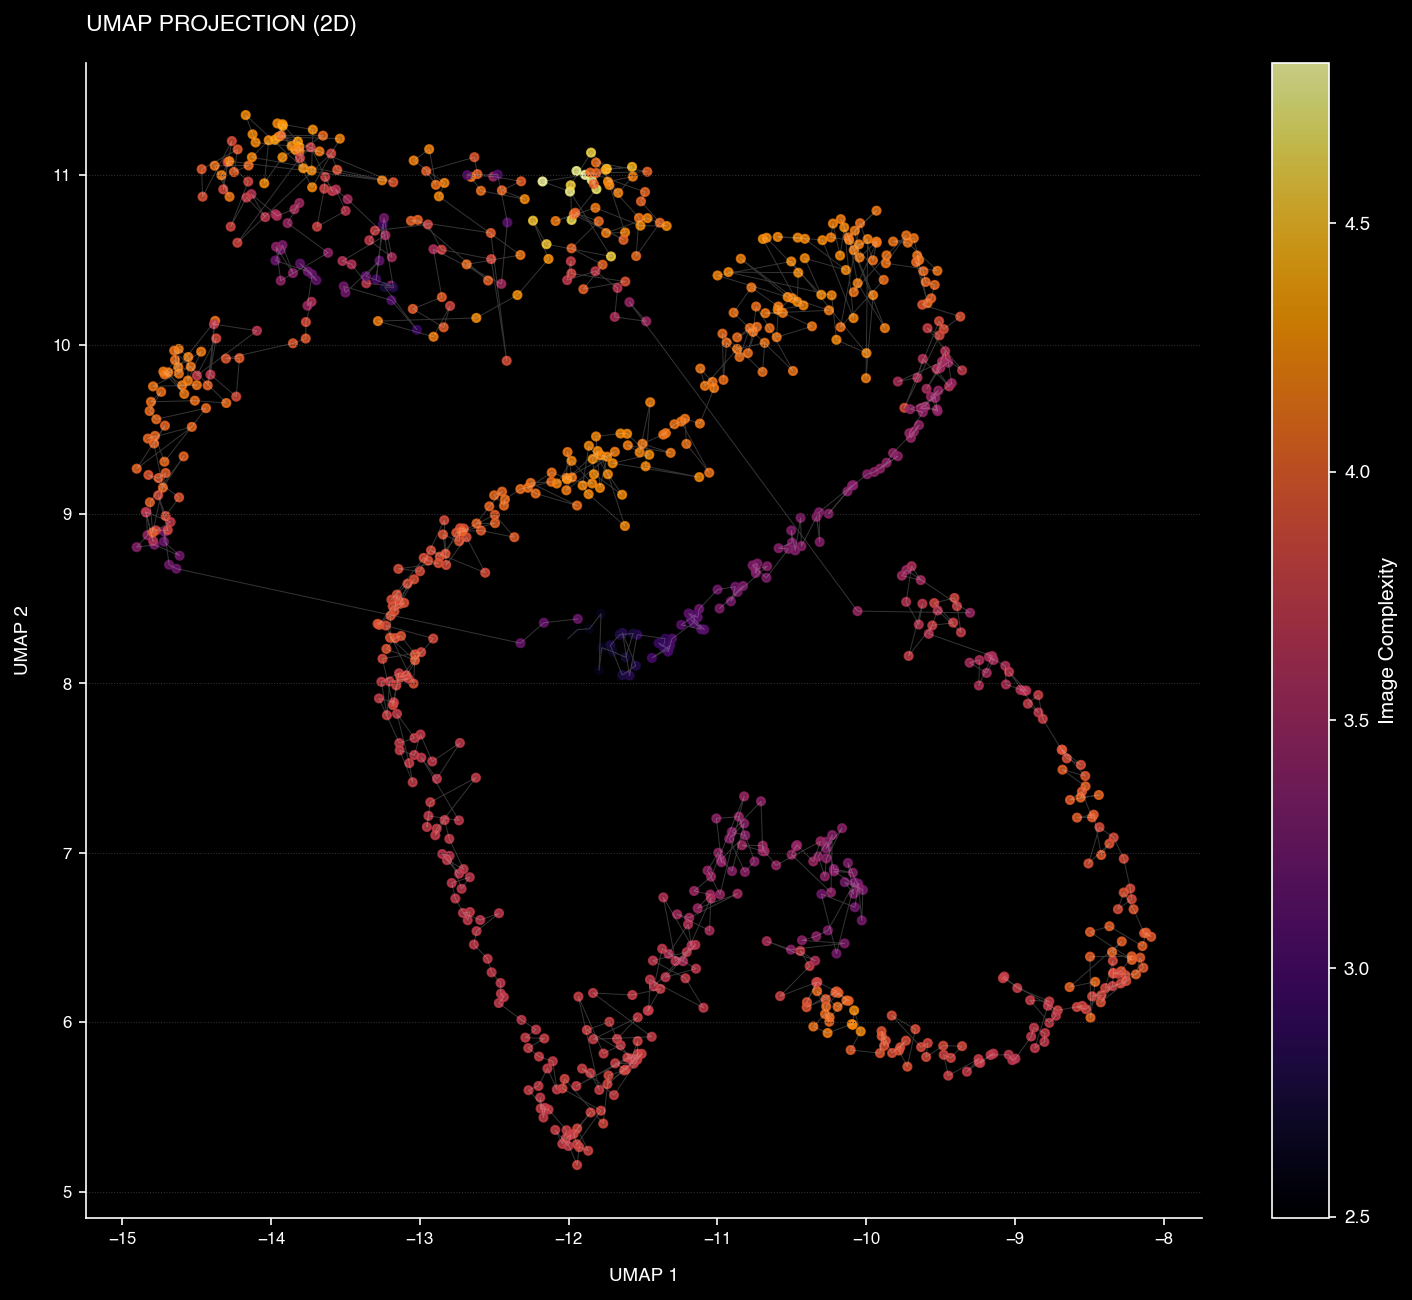

Running UMAP (3D)...


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [8]:
# Prepare Data
X = average_response_matrix_total.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Running UMAP (2D)...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)

# 2D Visualization
fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=frame_complexity, cmap='inferno', s=15, alpha=0.8)
ax.plot(embedding[:, 0], embedding[:, 1], color=viz_style.WHITE, alpha=0.2, linewidth=0.5)

viz_style.format_axis(ax, title='UMAP PROJECTION (2D)', xlabel='UMAP 1', ylabel='UMAP 2')
plt.colorbar(sc, label='Image Complexity')
plt.show()

# 3D Interactive Visualization
print("Running UMAP (3D)...")
reducer_3d = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=3, random_state=42)
embedding_3d = reducer_3d.fit_transform(X_scaled)

df_umap_3d = pd.DataFrame(embedding_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap_3d['Frame'] = np.arange(len(df_umap_3d))
df_umap_3d['Complexity'] = frame_complexity

fig = px.scatter_3d(
    df_umap_3d, x='UMAP1', y='UMAP2', z='UMAP3',
    color='Frame',
    hover_data=['Complexity'],
    title='3D UMAP Projection (Colored by Time)',
    color_continuous_scale='Turbo',
    opacity=0.6, width=800, height=800
)
fig.update_traces(marker=dict(size=3))
fig.show()

### Step 4: Brain State Identification (Clustering)
Cluster the neural activity patterns to identify distinct "Brain States" and analyze transitions between them.

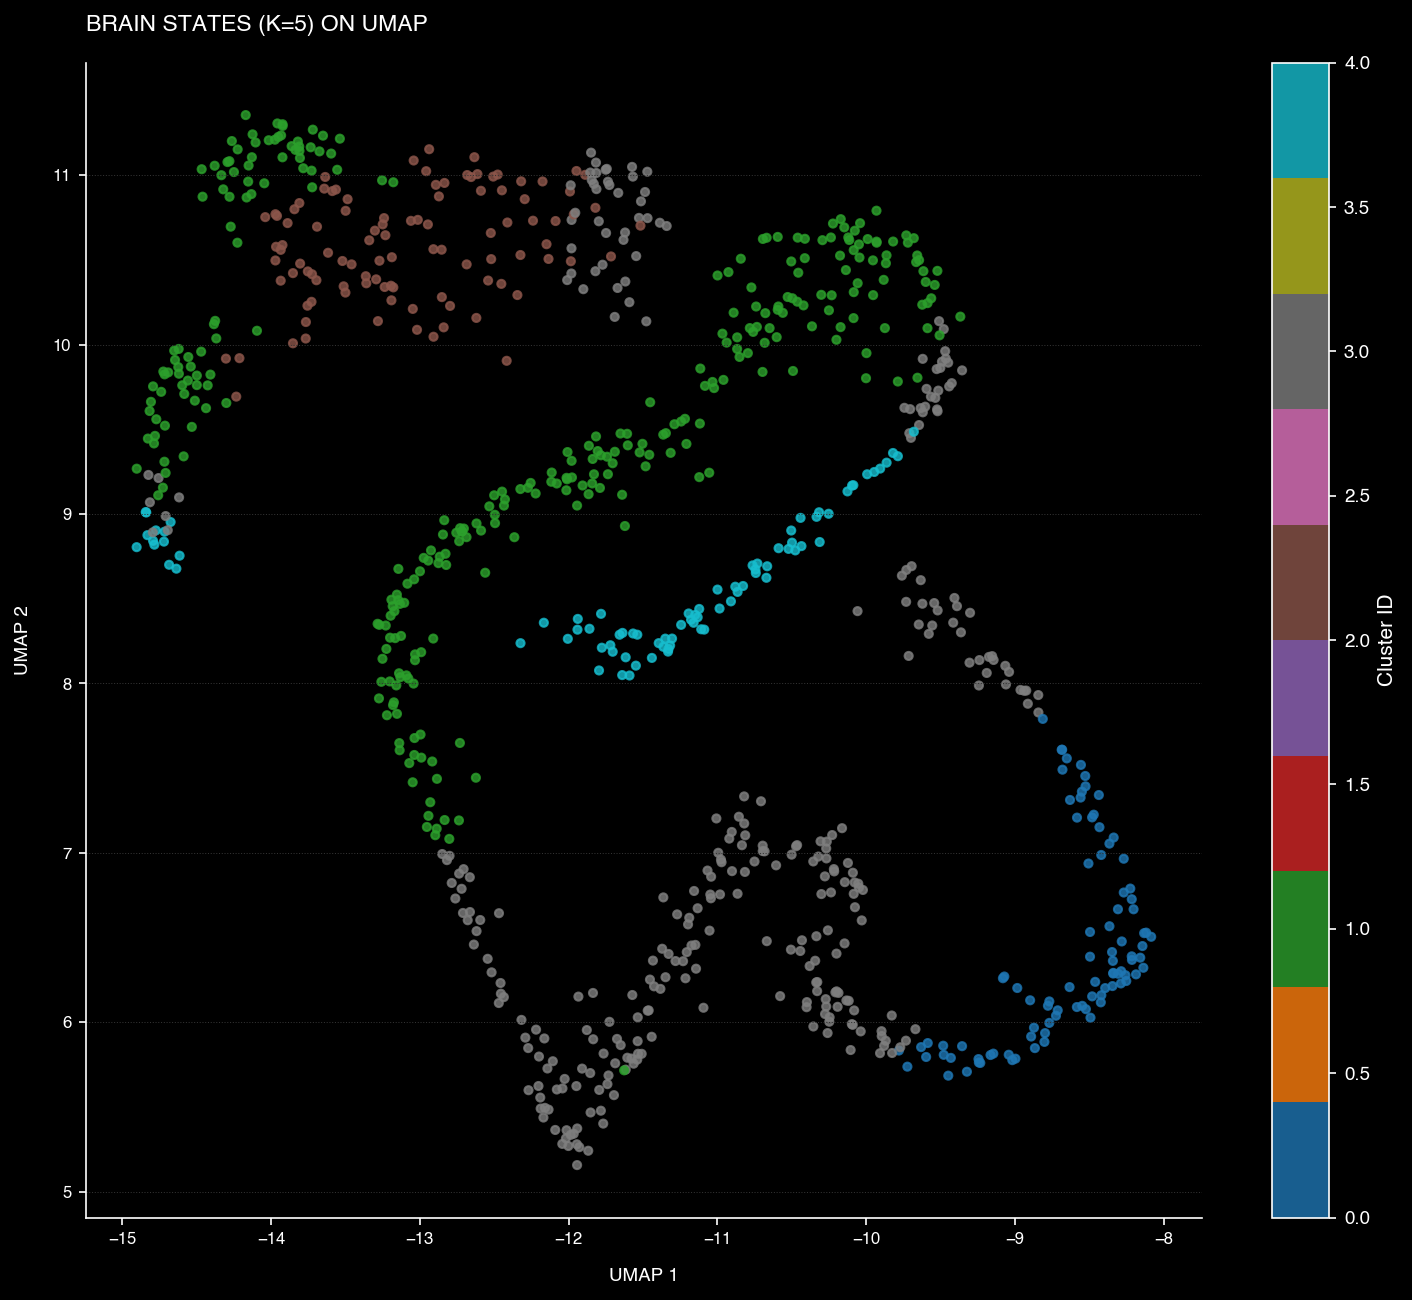

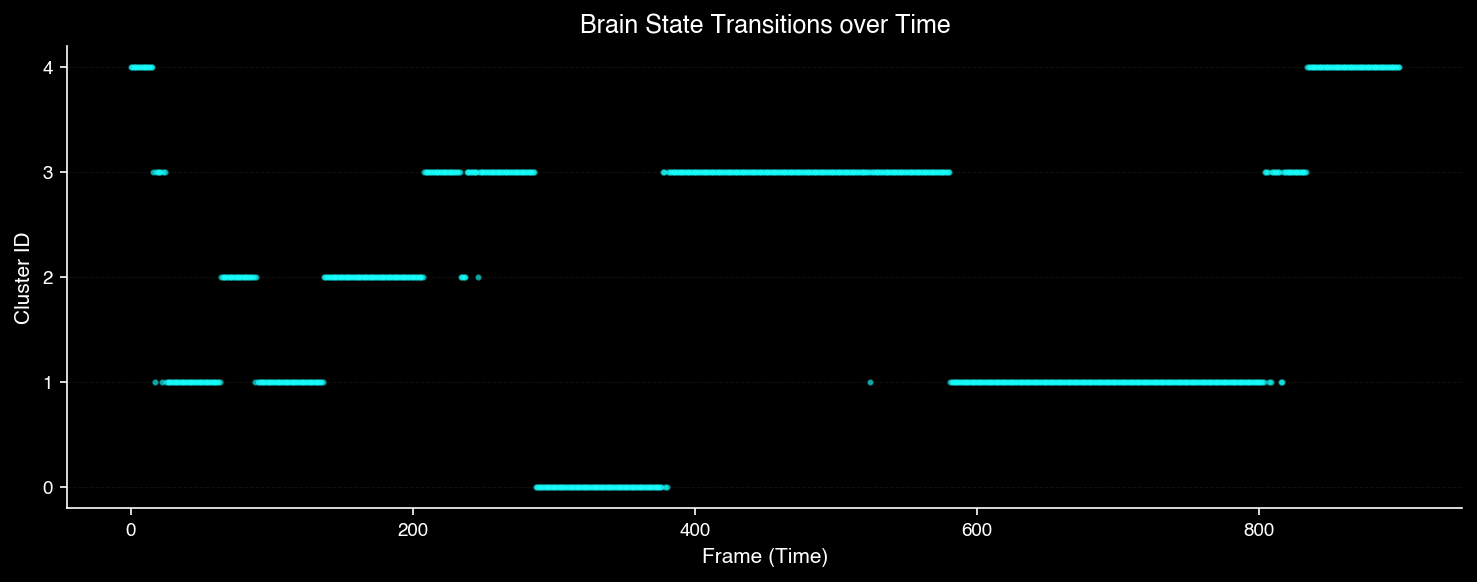

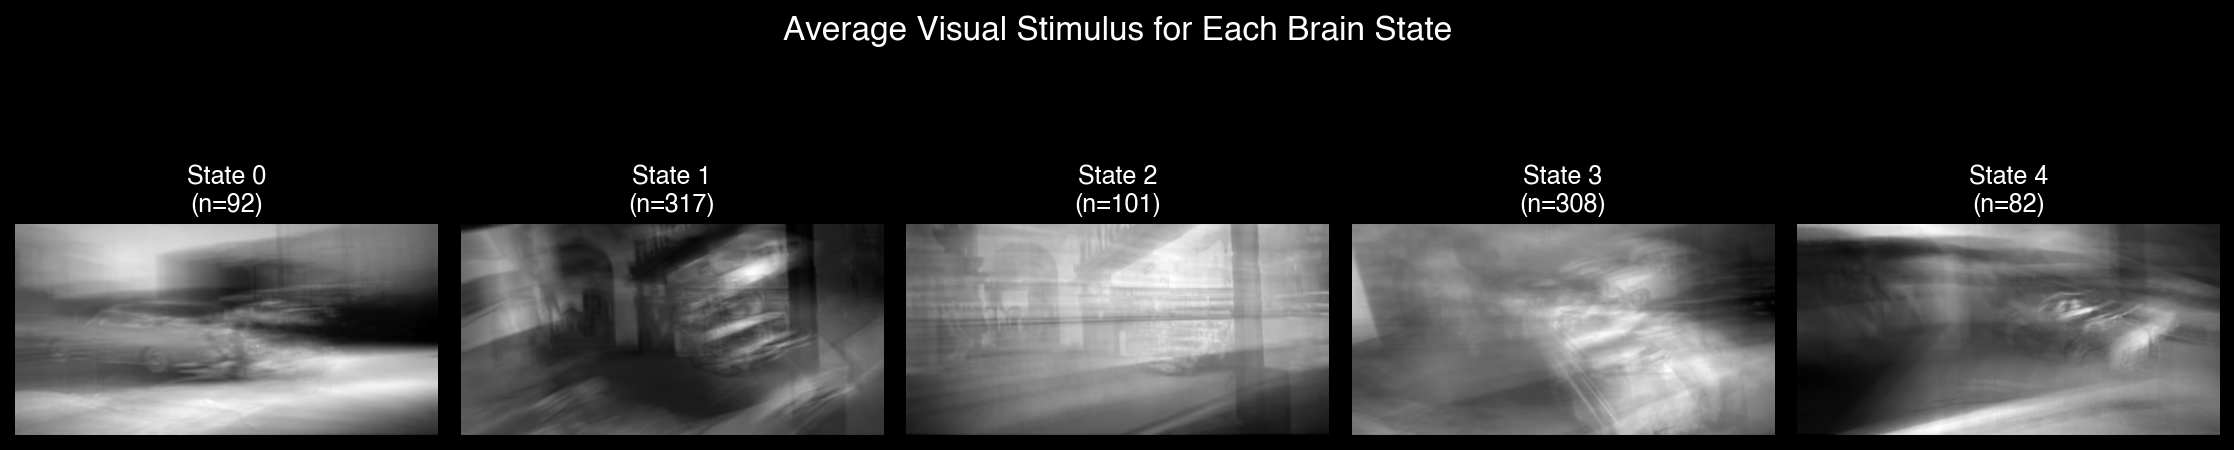

In [9]:
# K-Means Clustering on PCA data (usually more robust than raw)
pca = PCA(n_components=10)
X_pca_10 = pca.fit_transform(X_scaled)

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca_10)

# Visualize Clusters on UMAP
fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=cluster_labels, cmap='tab10', s=15, alpha=0.8)
viz_style.format_axis(ax, title=f'BRAIN STATES (K={n_clusters}) ON UMAP', xlabel='UMAP 1', ylabel='UMAP 2')
plt.colorbar(sc, label='Cluster ID')
plt.show()

# State Transitions
plt.figure(figsize=(12, 4))
plt.plot(cluster_labels, marker='o', linestyle='None', markersize=2, alpha=0.5, color=viz_style.CYAN)
plt.xlabel("Frame (Time)")
plt.ylabel("Cluster ID")
plt.title("Brain State Transitions over Time")
plt.yticks(range(n_clusters))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Average Stimulus per Cluster
fig, axes = plt.subplots(1, n_clusters, figsize=(15, 4))
fig.suptitle(f"Average Visual Stimulus for Each Brain State", fontsize=16)

for i in range(n_clusters):
    indices = np.where(cluster_labels == i)[0]
    if len(indices) > 0:
        mean_image = np.mean(movie_template[indices], axis=0)
        axes[i].imshow(mean_image, cmap='gray')
        axes[i].set_title(f"State {i}\n(n={len(indices)})")
        axes[i].axis('off')
plt.tight_layout()
plt.show()